In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix)
from scipy.stats import norm
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression


#EXERCISE 1


np.random.seed(42)


normal_temp = np.random.normal(35, 2, 150)
normal_current = np.random.normal(1.3, 0.1, 150)

abnormal_temp = np.random.normal(44, 2.5, 50)
abnormal_current = np.random.normal(1.7, 0.15, 50)

temperature = np.concatenate([normal_temp, abnormal_temp])
current = np.concatenate([normal_current, abnormal_current])

X = pd.DataFrame({
    "temperature": temperature,
    "current": current
})

y = np.array([0]*150 + [1]*50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", accuracy)
print(classification_report(y_test, y_pred))
print("Confusion matrix: ", confusion_matrix(y_test, y_pred))

Accuracy:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion matrix:  [[30  0]
 [ 0 10]]


Accuracy:  0.8


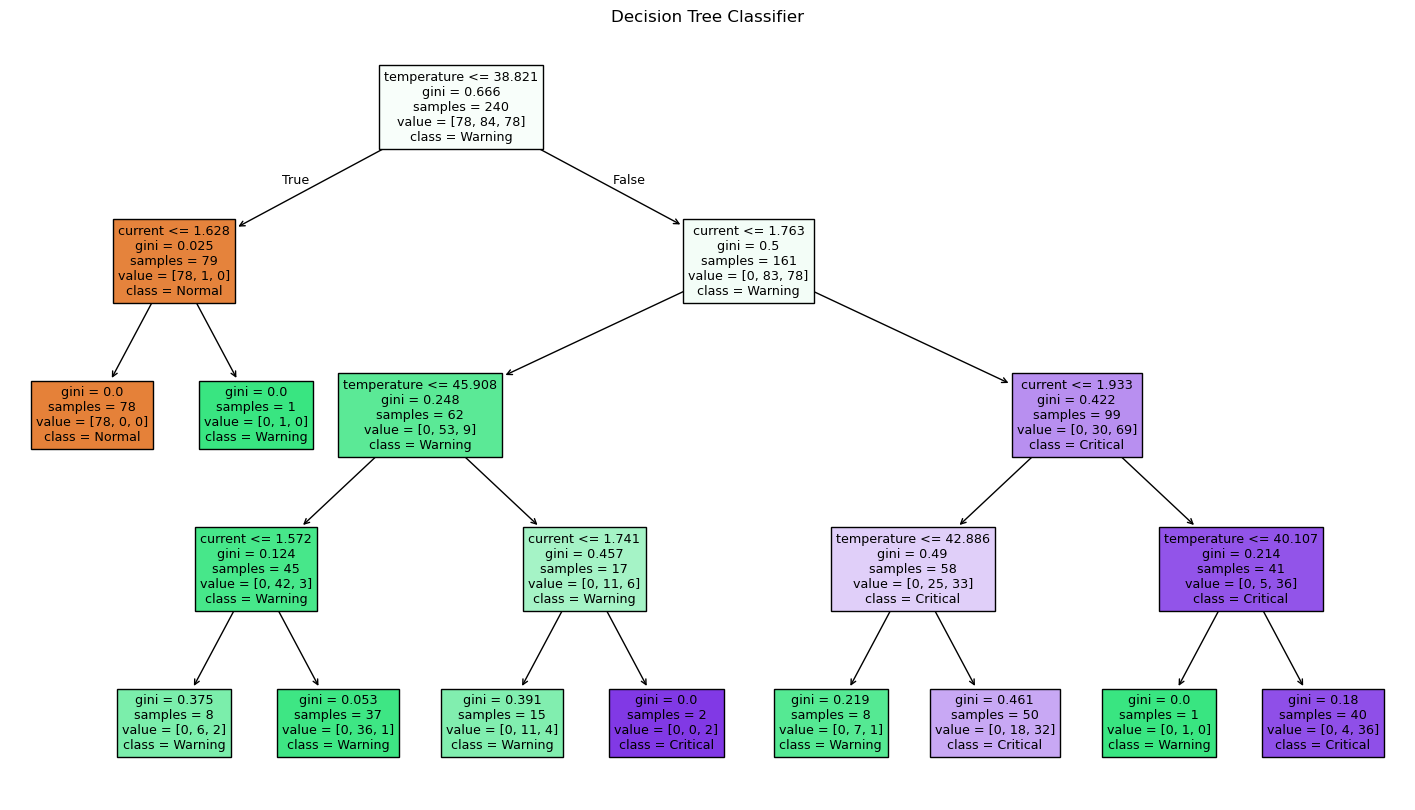

In [5]:
# EXERCISE 2

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

np.random.seed(42)

normal_temp = np.random.normal(35, 2, 100)
normal_current = np.random.normal(1.3, 0.1, 100)

warning_temp = np.random.normal(44, 2.5, 100)
warning_current = np.random.normal(1.7, 0.15, 100)

critical_temp = np.random.normal(46, 2.5, 100)
critical_current = np.random.normal(1.9, 0.15, 100)


temperature = np.concatenate([normal_temp, warning_temp, critical_temp])
current = np.concatenate([normal_current, warning_current, critical_current])


X = pd.DataFrame({
    "temperature" : temperature,
    "current" : current
})

y = np.array(
    [0]*100 +
    [1]*100 +
    [2]*100
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


model = DecisionTreeClassifier(max_depth = 4, random_state = 42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", Accuracy)


plt.figure(figsize = (18, 10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['Normal', 'Warning', 'Critical'],
    filled = True
)

plt.title("Decision Tree Classifier")

plt.show()    


cm [[22  0  0]
 [ 0 12  4]
 [ 0  8 14]]


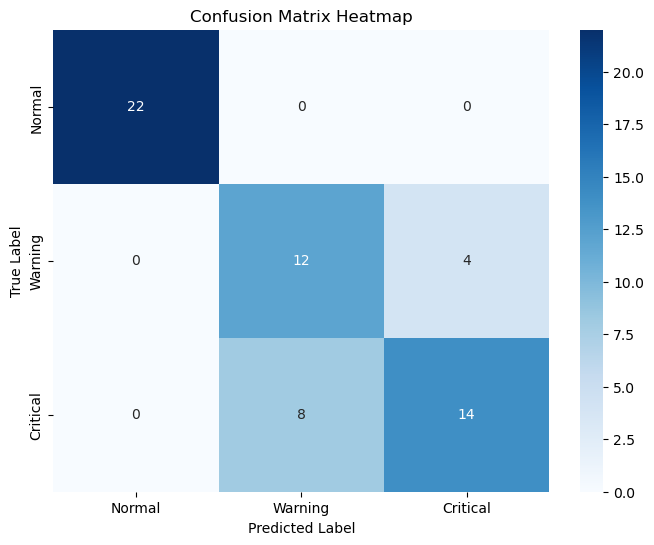

Critical Precision: 0.7777777777777778
Critical Recall: 0.6363636363636364
Critical False Negative Rate: 0.36363636363636365


In [6]:
# EXERCISE 3

import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
print("cm", cm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Warning", "Critical"],
    yticklabels=["Normal", "Warning", "Critical"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")

plt.show()



TP = cm[2, 2]

FN = cm[2, 0] + cm[2, 1]

FP = cm[0, 2] + cm[1, 2]

precision = TP / (TP + FP)

recall = TP / (TP + FN)

fnr = FN / (TP + FN)

print("Critical Precision:", precision)

print("Critical Recall:", recall)

print("Critical False Negative Rate:", fnr)

In [7]:
# EXERCISE 4

from sklearn.neighbors import KNeighborsClassifier

# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)

# X_test_scaled = scaler.transform(X_test)


k_values =[3, 5, 11]
models = {}
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    models[k] = model
    
for k, model in models.items():
    
    y_pred = model.predict(X_test)

    Accuracy = accuracy_score(y_test, y_pred)
    
    print(f"k = {k} --> Accuracy = {accuracy:.4f}")

    



k = 3 --> Accuracy = 1.0000
k = 5 --> Accuracy = 1.0000
k = 11 --> Accuracy = 1.0000


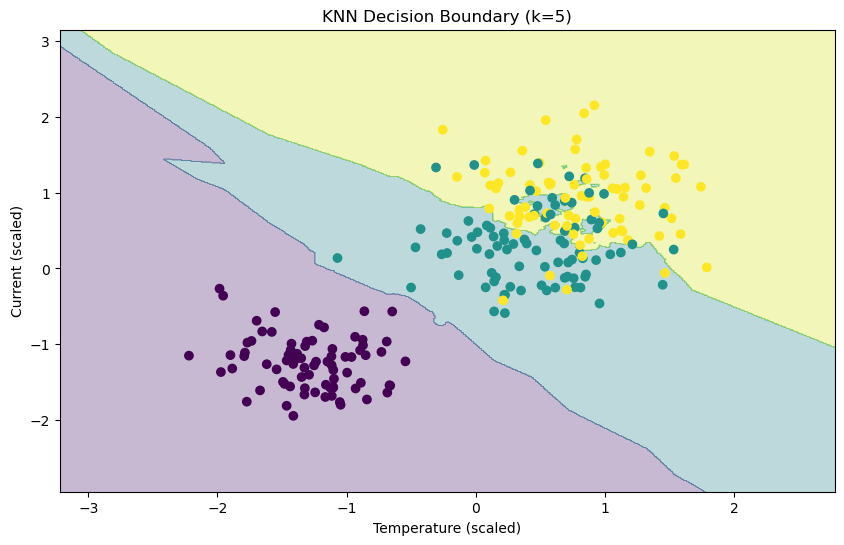

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# -----------------------------------
# Scale features
# -----------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# -----------------------------------
# Train KNN model (k=5)
# -----------------------------------

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# -----------------------------------
# Create mesh grid
# -----------------------------------

x_min, x_max = (
    X_train_scaled[:, 0].min() - 1,
    X_train_scaled[:, 0].max() + 1
)

y_min, y_max = (
    X_train_scaled[:, 1].min() - 1,
    X_train_scaled[:, 1].max() + 1
)

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# -----------------------------------
# Predict every point in the grid
# -----------------------------------

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = knn.predict(grid_points)

# Reshape predictions
Z = Z.reshape(xx.shape)

# -----------------------------------
# Plot decision boundary
# -----------------------------------

plt.figure(figsize=(10, 6))

# Colored regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Training points
scatter = plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train
)

plt.xlabel("Temperature (scaled)")
plt.ylabel("Current (scaled)")
plt.title("KNN Decision Boundary (k=5)")

plt.show()


Logistic Regression
Accuracy: 0.7666666666666667
Macro F1: 0.7543859649122807
Confusion Matrix:
 [[22  0  0]
 [ 0 12  4]
 [ 0 10 12]]

Decision Tree
Accuracy: 0.8
Macro F1: 0.7888888888888888
Confusion Matrix:
 [[22  0  0]
 [ 0 12  4]
 [ 0  8 14]]

KNN
Accuracy: 0.75
Macro F1: 0.7322057787174066
Confusion Matrix:
 [[22  0  0]
 [ 0  9  7]
 [ 0  8 14]]


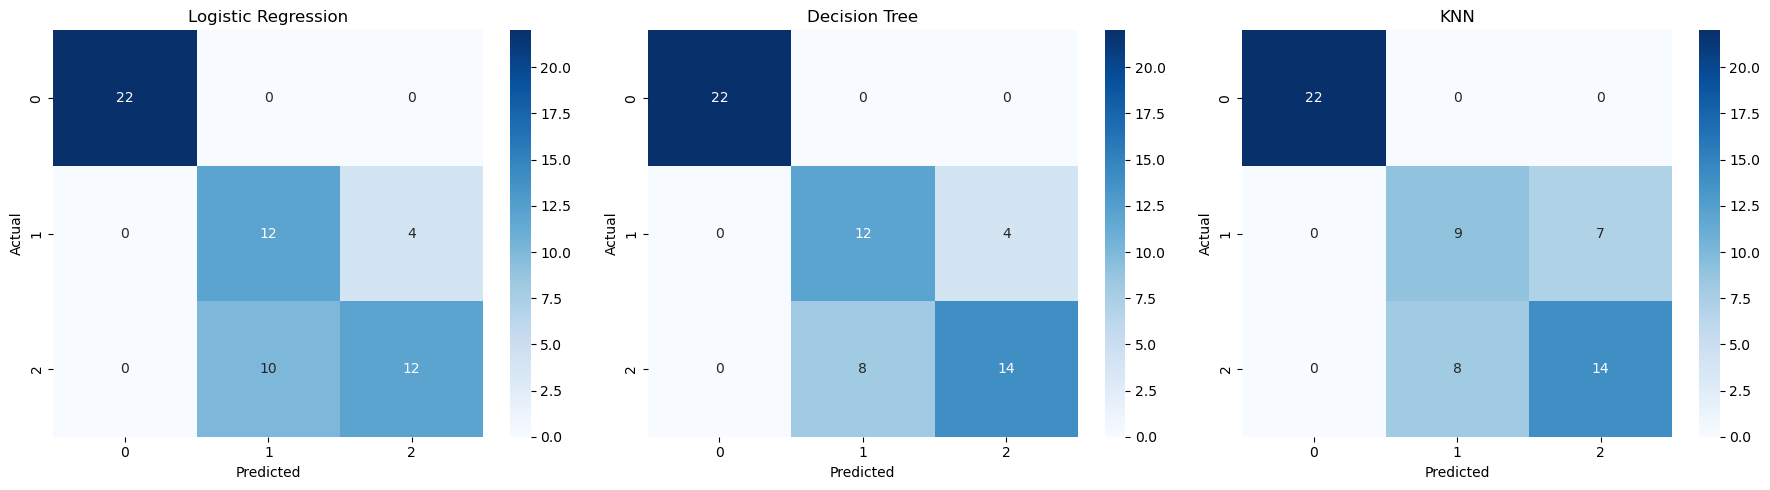

In [9]:
#EXERCISE 5



from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# ---------------- Logistic Regression ----------------
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# ---------------- Decision Tree ----------------
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

# ---------------- KNN ----------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)


def evaluate(name, y_true, y_pred):
    print(f"\n{name}")

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


evaluate("Logistic Regression", y_test, log_pred)
evaluate("Decision Tree", y_test, tree_pred)
evaluate("KNN", y_test, knn_pred)





fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Logistic Regression", log_pred),
    ("Decision Tree", tree_pred),
    ("KNN", knn_pred)
]

for i, (name, pred) in enumerate(models):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.61      0.69      0.65        16
           2       0.75      0.68      0.71        22

    accuracy                           0.80        60
   macro avg       0.79      0.79      0.79        60
weighted avg       0.80      0.80      0.80        60



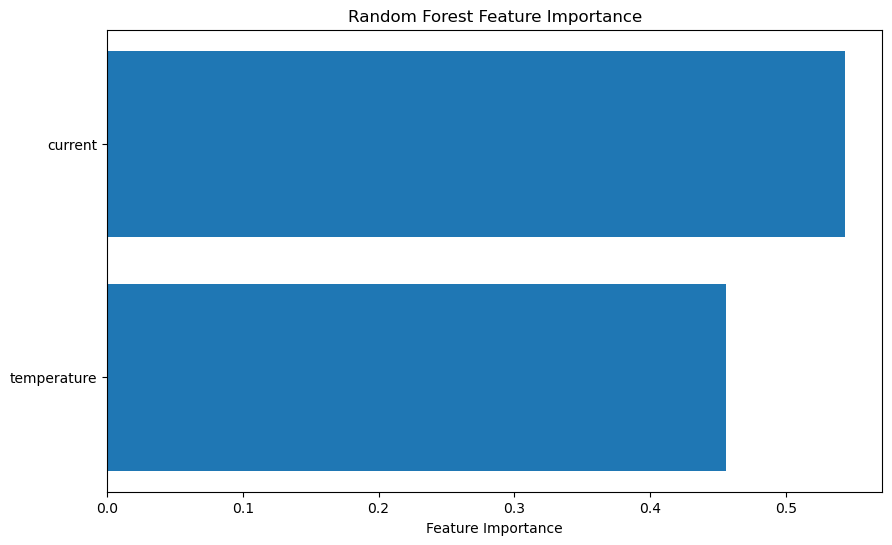

In [10]:
#EXERCISE 6


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

importances = rf_model.feature_importances_
features = X.columns


sorted_idx = np.argsort(importances)

plt.figure(figsize=(10, 6))

plt.barh(features[sorted_idx], importances[sorted_idx])

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [11]:
# EXERCISE 7


from sklearn.metrics import confusion_matrix, recall_score

np.random.seed(42)

# -------------------------
# Normal class (0)
# -------------------------
normal_temp = np.random.normal(35, 2, 500)
normal_current = np.random.normal(1.3, 0.1, 500)

# -------------------------
# Fault class (1)
# -------------------------
fault_temp = np.random.normal(44, 2.5, 25)
fault_current = np.random.normal(1.7, 0.15, 25)

# -------------------------
# Combine
# -------------------------
X = pd.DataFrame({
    "temperature": np.concatenate([normal_temp, fault_temp]),
    "current": np.concatenate([normal_current, fault_current])
})

y = np.array([0]*500 + [1]*25)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Standard Logistic Regression
# -------------------------
model1 = LogisticRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

cm1 = confusion_matrix(y_test, y_pred1)

print("Confusion Matrix (Standard):\n", cm1)
print("Fault Recall:", recall_score(y_test, y_pred1))

# class weight balance

model2 = LogisticRegression(class_weight="balanced")

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

cm2 = confusion_matrix(y_test, y_pred2)

print("Confusion Matrix (Balanced):\n", cm2)
print("Fault Recall:", recall_score(y_test, y_pred2))


# smote over sampling

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

model3 = LogisticRegression()
model3.fit(X_resampled, y_resampled)

y_pred3 = model3.predict(X_test)

cm3 = confusion_matrix(y_test, y_pred3)

print("Confusion Matrix (SMOTE):\n", cm3)
print("Fault Recall:", recall_score(y_test, y_pred3))

print("\nRecall Comparison (Fault class):")
print("Standard:", recall_score(y_test, y_pred1))
print("Class Weight:", recall_score(y_test, y_pred2))
print("SMOTE:", recall_score(y_test, y_pred3))

Confusion Matrix (Standard):
 [[96  1]
 [ 0  8]]
Fault Recall: 1.0
Confusion Matrix (Balanced):
 [[96  1]
 [ 0  8]]
Fault Recall: 1.0


ModuleNotFoundError: No module named 'imblearn'

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_per_class = 200  # 3 classes → 600 samples

# ---------------- NORMAL ----------------
temp_n = np.random.normal(35, 2, n_per_class)
curr_n = np.random.normal(1.2, 0.1, n_per_class)
vib_n = np.random.normal(0.5, 0.1, n_per_class)
volt_n = np.random.normal(2, 0.2, n_per_class)
hrs_n = np.random.uniform(100, 500, n_per_class)

# ---------------- WARNING ----------------
temp_w = np.random.normal(42, 2, n_per_class)
curr_w = np.random.normal(1.5, 0.15, n_per_class)
vib_w = np.random.normal(0.9, 0.15, n_per_class)
volt_w = np.random.normal(3, 0.3, n_per_class)
hrs_w = np.random.uniform(300, 900, n_per_class)

# ---------------- CRITICAL ----------------
temp_c = np.random.normal(48, 2.5, n_per_class)
curr_c = np.random.normal(1.9, 0.2, n_per_class)
vib_c = np.random.normal(1.3, 0.2, n_per_class)
volt_c = np.random.normal(4, 0.4, n_per_class)
hrs_c = np.random.uniform(600, 1200, n_per_class)

# ---------------- COMBINE ----------------
X = pd.DataFrame({
    "temperature": np.concatenate([temp_n, temp_w, temp_c]),
    "current": np.concatenate([curr_n, curr_w, curr_c]),
    "vibration": np.concatenate([vib_n, vib_w, vib_c]),
    "voltage_drop": np.concatenate([volt_n, volt_w, volt_c]),
    "operating_hours": np.concatenate([hrs_n, hrs_w, hrs_c])
})

y = np.array([0]*200 + [1]*200 + [2]*200)

X["power_ratio"] = X["current"] * X["voltage_drop"]

X["stress_index"] = X["temperature"] * X["vibration"]

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_rf = Pipeline([
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_gb = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42))
])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.model_selection import cross_val_score

def evaluate_model(name, model):

    acc = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    f1 = cross_val_score(model, X_train, y_train, cv=5, scoring="f1_weighted")

    print(f"\n{name}")
    print("Accuracy:", acc.mean(), "+/-", acc.std())
    print("F1-score:", f1.mean(), "+/-", f1.std())

evaluate_model("Logistic Regression", pipe_lr)
evaluate_model("Random Forest", pipe_rf)
evaluate_model("Gradient Boosting", pipe_gb)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_gb
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(cm, annot=True, fmt="d", ax=axes[i], cmap="Blues")

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

best_model = pipe_gb   # usually best in this setup
best_model.fit(X_train, y_train)

from joblib import dump

dump(best_model, "fault_model.pkl")

from joblib import load

loaded_model = load("fault_model.pkl")

new_data = pd.DataFrame([
    [45, 1.6, 1.0, 3.5, 500, 1.6*3.5, 45*1.0],
    [38, 1.3, 0.6, 2.2, 200, 1.3*2.2, 38*0.6],
    [50, 2.0, 1.4, 4.0, 800, 2.0*4.0, 50*1.4]
], columns=X.columns)

preds = loaded_model.predict(new_data)
probs = loaded_model.predict_proba(new_data)

for i in range(len(new_data)):
    print("\nSample", i+1)
    print("Prediction:", preds[i])
    print("Confidence:", probs[i])